In [1]:
import sys
sys.path.append('../')
from data.cholec_scene_graph import CholecSceneGraphDataset
from data.cataracts_scene_graph2 import CataractSceneGraphDataset
import matplotlib.pyplot as plt
import einops

In [2]:
d = CataractSceneGraphDataset("train", num_frames=8)

Loading those frame indices [-30 -26 -21 -17 -13  -9  -4   0] for each sample


In [ ]:
possible_pairs = {}
for video_name, frame_idx, triplets in d.video_frame_tuples:
    rel_dict = d.build_relations_dict(triplets)
    for pair, relation_vector in rel_dict.items():
        if pair not in possible_pairs:
            possible_pairs[pair] = relation_vector.bool()
        else:
            possible_pairs[pair] |= relation_vector.bool()

In [4]:
{k: v.int() for k,v in possible_pairs.items()}

{(15, 1): tensor([1, 1, 0, 0, 1, 0, 0], dtype=torch.int32),
 (10, 1): tensor([1, 1, 1, 1, 1, 0, 0], dtype=torch.int32),
 (15, 7): tensor([0, 1, 0, 0, 1, 1, 1], dtype=torch.int32),
 (10, 7): tensor([1, 0, 1, 1, 0, 1, 1], dtype=torch.int32),
 (11, 7): tensor([0, 0, 0, 0, 1, 1, 1], dtype=torch.int32),
 (11, 1): tensor([1, 1, 0, 0, 1, 0, 0], dtype=torch.int32),
 (8, 7): tensor([1, 1, 0, 1, 0, 1, 1], dtype=torch.int32),
 (8, 1): tensor([1, 1, 1, 1, 0, 0, 0], dtype=torch.int32),
 (9, 7): tensor([0, 0, 0, 0, 0, 1, 1], dtype=torch.int32),
 (9, 1): tensor([1, 1, 1, 1, 1, 0, 0], dtype=torch.int32),
 (17, 7): tensor([1, 1, 0, 1, 0, 1, 1], dtype=torch.int32),
 (17, 1): tensor([1, 1, 1, 1, 1, 0, 0], dtype=torch.int32),
 (12, 7): tensor([1, 1, 1, 1, 0, 1, 1], dtype=torch.int32),
 (12, 5): tensor([0, 1, 1, 0, 0, 0, 0], dtype=torch.int32),
 (12, 1): tensor([1, 1, 1, 1, 0, 0, 0], dtype=torch.int32),
 (16, 7): tensor([1, 1, 0, 1, 0, 1, 1], dtype=torch.int32),
 (16, 1): tensor([1, 1, 1, 1, 1, 0, 0], dtyp

In [5]:
occurence_list = d.get_occurence_list()

AttributeError: 'CataractSceneGraphDataset' object has no attribute 'get_occurence_list'

In [ ]:
idx = occurence_list[3][100]
coagulate_sample = d[idx]

In [ ]:
coagulate_sample["relations_dict"]

{(9, 7): tensor([0., 0., 0., 1., 0., 0., 0., 0., 0.])}

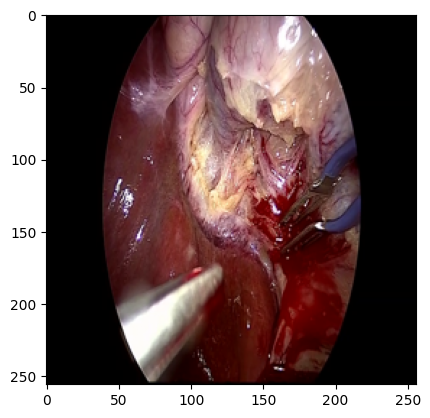

In [ ]:
plt.imshow(einops.rearrange(coagulate_sample["frames"][-1], "c h w -> h w c"))